## Sentiment Classification of IMDb Movie Reviews with Recurrent Neural Networks

---

## 1. Problem Context

Movie ratings and reviews are a rich source of textual data that can be analyzed to identify underlying user sentiment. In this microproject, we address a **binary sentiment classification** task on IMDb movie reviews, where each text must be classified as either positive or negative.

Recurrent neural networks are well-suited for this problem because they process sequences and can capture dependencies between words. In particular, architectures such as `GRU` and `LSTM` enable modeling relevant contextual information to estimate review polarity.

Dataset used:

- Kaggle: [IMDb Movie Ratings Sentiment Analysis](https://www.kaggle.com/datasets/yasserh/imdb-movie-ratings-sentiment-analysis/data)

## 2. Objective

Develop a recurrent neural network-based method to accurately classify IMDb movie reviews into one of two categories: **positive** or **negative**.

To achieve this goal, a pipeline is built that includes text cleaning, tokenization, vocabulary construction, sequence padding/truncation, training of a `Bi-GRU` network, and evaluation using accuracy, precision, recall, F1-score, and confusion matrix.

## 3. Initial Setup

Main libraries are imported and the base configuration of the experiment is defined. This version preserves the results from the `Microproyecto-02_pt01.ipynb` notebook, making explicit the variables that previously depended on the prior kernel state.

In [4]:
# Import libraries
from collections import Counter
from pathlib import Path
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

BASE_DIR = Path.cwd()
DATASET_PATH = BASE_DIR / "dataset" / "movie.csv"
MODEL_PATH = BASE_DIR / "best_sentiment_gru_checkpoint.pth"
GLOVE_PATH = BASE_DIR / "embeddings" / "glove.6B.100d"
GLOVE_MODEL_PATH = BASE_DIR / "best_sentiment_gru_glove_checkpoint.pth"

RANDOM_SEED = 42
MAX_WORDS = 10_000
MAX_LEN = 230
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.3
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 15

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Directorio base: {BASE_DIR}")
print(f"Dataset: {DATASET_PATH}")
print(f"Dispositivo seleccionado: {device}")

Directorio base: c:\Users\Sergio\Documents\GitHub\microproyecto-02-tdl
Dataset: c:\Users\Sergio\Documents\GitHub\microproyecto-02-tdl\dataset\movie.csv
Dispositivo seleccionado: cpu


## 4. Dataset

The dataset is loaded from `Microproyecto 02/dataset/movie.csv`. The file contains movie reviews along with a binary sentiment label, where `0` represents negative sentiment and `1` represents positive sentiment.

In [5]:
# Load dataset
df = pd.read_csv(DATASET_PATH)
df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [6]:
# Inspect sample rows from the dataset
# HTML tags, special characters, redundant whitespace, and mixed capitalization are present
df

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1
...,...,...
39995,"""Western Union"" is something of a forgotten cl...",1
39996,This movie is an incredible piece of work. It ...,1
39997,My wife and I watched this movie because we pl...,0
39998,"When I first watched Flatliners, I was amazed....",1


In [7]:
# Get general dataset information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB
None


## 5. Dataset Exploration and Cleaning

In this section, duplicates, class balance, and textual noise are reviewed. Cleaning focuses on removing HTML tags, special characters, numbers, uppercase letters, and redundant whitespace to facilitate tokenization.

### 5.1 Duplicate Rows Check

In [8]:
duplicados_totales = df.duplicated(subset=['text']).sum()
print(f"Número de reseñas duplicadas: {duplicados_totales}")

Número de reseñas duplicadas: 277


Having identical reviews can introduce bias into RNN training or cause `data leakage` if the same review appears in both training and test sets. For this reason, exact duplicates are removed based on the `text` column.

In [9]:
# Remove duplicate rows
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Nuevo total de reseñas únicas: {len(df)}")

Nuevo total de reseñas únicas: 39723


### 5.2 Class Balance Check

Etiquetas con sentimiento Negativo: 19815
Etiquetas con sentimiento Positivo: 19908



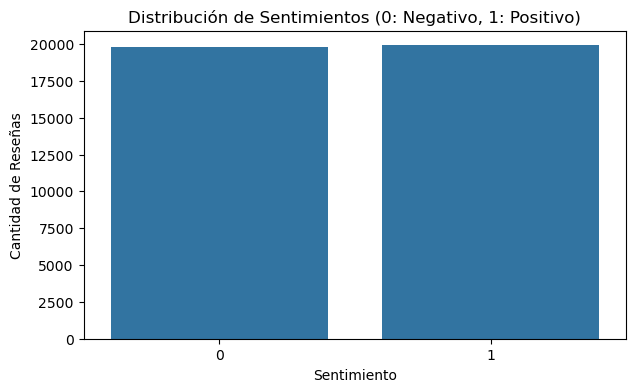

In [10]:
# 'label' column corresponds to 0: Negative and 1: Positive
# Count label frequencies to check class balance

negativos = df['label'].value_counts().get(0, 0)
positivos = df['label'].value_counts().get(1, 0)

print(f"Etiquetas con sentimiento Negativo: {negativos}")
print(f"Etiquetas con sentimiento Positivo: {positivos}\n")

# Plot class distribution
plt.figure(figsize=(7, 4))
sns.countplot(x='label', data=df)
plt.title('Distribución de Sentimientos (0: Negativo, 1: Positivo)')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de Reseñas')
plt.show()

The dataset remains virtually balanced after removing duplicates: `19,815` negative reviews and `19,908` positive reviews. The difference is only `93` records, so neither resampling nor class weighting is performed.

### 5.3 Text Cleaning Pipeline

During initial exploration, HTML tags, special characters, redundant whitespace, and mixed capitalization are identified. A regular expression-based cleaning pipeline is applied to normalize texts before building the vocabulary.

Numbers are also removed. While some could provide signals—such as explicit ratings like `10/10`—in this experiment they are considered redundant compared to the textual context and the sentiment label.

In [11]:
def clean_review(text):
    # Remove HTML tags
    text = re.sub(r'<[^>]*>', ' ', text)
    
    # Remove non-alphabetic characters (punctuation and numbers)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to the dataset text column
df['text_cleaned'] = df['text'].apply(clean_review)

In [12]:
# Display sample cleaned reviews
df

,text,label,text_cleaned
0,I grew up (b. 1965) watching and loving the Th...,0,i grew up b watching and loving the thunderbir...
1,"When I put this movie in my DVD player, and sa...",0,when i put this movie in my dvd player and sat...
2,Why do people who do not know what a particula...,0,why do people who do not know what a particula...
3,Even though I have great interest in Biblical ...,0,even though i have great interest in biblical ...
4,Im a die hard Dads Army fan and nothing will e...,1,im a die hard dads army fan and nothing will e...
...,...,...,...
39718,"""Western Union"" is something of a forgotten cl...",1,western union is something of a forgotten clas...
39719,This movie is an incredible piece of work. It ...,1,this movie is an incredible piece of work it e...
39720,My wife and I watched this movie because we pl...,0,my wife and i watched this movie because we pl...
39721,"When I first watched Flatliners, I was amazed....",1,when i first watched flatliners i was amazed i...


### 5.4 Review Length Analysis

Before tokenizing, review lengths are analyzed to select an appropriate maximum sequence length. This allows controlling computational cost and mitigating the impact of very long outliers.

Estadísticas de longitud de las reseñas:
count    39723.000000
mean       227.169524
std        168.195195
min          4.000000
25%        124.000000
50%        170.000000
75%        276.000000
max       2450.000000
Name: review_length, dtype: float64


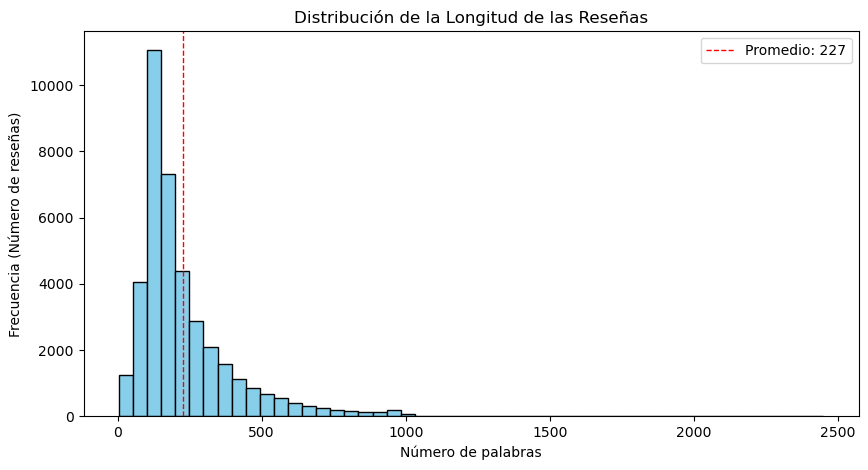

In [13]:
# Calculate review length via word count
df['review_length'] = df['text_cleaned'].apply(lambda x: len(x.split()))

# Review descriptive statistics
print("Estadísticas de longitud de las reseñas:")
print(df['review_length'].describe())

# Plot histogram distribution
plt.figure(figsize=(10, 5))
plt.hist(df['review_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de la Longitud de las Reseñas')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia (Número de reseñas)')
plt.axvline(df['review_length'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Promedio: {df["review_length"].mean():.0f}')
plt.legend()
plt.show()

Based on the results, the average length is approximately `227` words, the median is `170`, the 75th percentile is `276`, and there are outliers reaching up to `2450` words. `MAX_LEN = 230` is chosen as a trade-off between retaining context and limiting memory/training cost.

## 6. Splitting, Tokenization, and Vocabulary Construction

To avoid data leakage, the dataset is first split into training, validation, and test sets using the cleaned reviews. Then, the vocabulary is constructed **using only the training set**.

Two special indices are reserved:

- `<PAD> = 0`: padding to pad shorter sequences.
- `<UNK> = 1`: unknown or out-of-vocabulary words.

Each review is then transformed into a fixed-length numerical sequence via truncation or padding.

In [14]:
# First split: 80% training and 20% temporary.
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text_cleaned"].values,
    df["label"].values,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df["label"].values,
)

# Second split: 10% validation and 10% test.
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=temp_labels,
)


def build_vocab(texts, max_words):
    word_counts = Counter()
    for text in texts:
        word_counts.update(text.split())

    # Word to index mapping. Starts at 2 to reserve PAD and UNK.
    vocab = {word: i + 2 for i, (word, _) in enumerate(word_counts.most_common(max_words))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab


vocab = build_vocab(train_texts, MAX_WORDS)
VOCAB_SIZE = len(vocab)


def tokenize_and_pad(text, vocab, max_len):
    sequence = [vocab.get(word, 1) for word in text.split()]

    if len(sequence) > max_len:
        return sequence[:max_len]
    return sequence + [0] * (max_len - len(sequence))


X_train = np.array([tokenize_and_pad(text, vocab, MAX_LEN) for text in train_texts])
X_val = np.array([tokenize_and_pad(text, vocab, MAX_LEN) for text in val_texts])
X_test = np.array([tokenize_and_pad(text, vocab, MAX_LEN) for text in test_texts])

y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(test_labels)

print(f"Vocabulario creado con {VOCAB_SIZE} tokens usando solo el conjunto de entrenamiento.")
print("Ejemplo de secuencia numérica:")
print(f"{X_train[0][:15]}...")

Vocabulario creado con 10002 tokens usando solo el conjunto de entrenamiento.
Ejemplo de secuencia numérica:
[  47   23   46  799   12  581   11   17   35  108    4  916 9847   18
   23]...


## 7. Dataset Split Summary

The final partition maintains a stratified proportion of `80%` training, `10%` validation, and `10%` testing.

In [15]:
def summarize_split(name, labels):
    counts = Counter(labels)
    print(
        f"{name}: {len(labels)} muestras | "
        f"Negativo={counts.get(0, 0)} | Positivo={counts.get(1, 0)}"
    )


summarize_split("Set de Entrenamiento", y_train)
summarize_split("Set de Validación", y_val)
summarize_split("Set de Prueba", y_test)

Set de Entrenamiento: 31778 muestras | Negativo=15852 | Positivo=15926
Set de Validación: 3972 muestras | Negativo=1981 | Positivo=1991
Set de Prueba: 3973 muestras | Negativo=1982 | Positivo=1991


## 8. Recurrent Architecture Development

The selected architecture is a bidirectional `GRU`. This choice enables capturing context in both directions of the sequence with lower computational cost compared to an equivalent `LSTM`.

Main components:

- `Embedding`: converts word indices into trainable dense vectors.
- `Bi-GRU`: processes the review from left to right and right to left.
- `Dropout`: reduces overfitting during training.
- `Linear`: projects the final hidden state to a binary logit.
- `BCEWithLogitsLoss`: combines sigmoid and binary cross-entropy in a numerically stable manner.

In [16]:
class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout=0.3):
        super(SentimentGRU, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            dropout=dropout,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, hidden = self.gru(embedded)
        hidden_cat = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        return self.fc(self.dropout(hidden_cat))


model = SentimentGRU(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, dropout=DROPOUT).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

SentimentGRU(
  (embedding): Embedding(10002, 100)
  (gru): GRU(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Parámetros entrenables: 1,473,545


## 9. DataLoader Preparation

In [17]:
# Convert arrays to PyTorch tensors.
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).float())
val_data = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val).float())
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test).float())

train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
val_loader = DataLoader(val_data, shuffle=False, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)

print(f"Batches de entrenamiento: {len(train_loader)}")
print(f"Batches de validación: {len(val_loader)}")
print(f"Batches de prueba: {len(test_loader)}")

Batches de entrenamiento: 497
Batches de validación: 63
Batches de prueba: 63


## 10. Model Training

The model is trained using `BCEWithLogitsLoss` and `Adam`. In each epoch, validation loss is computed and the best checkpoint is automatically saved whenever `val_loss` improves.

This approach prevents simply retaining the final training state. For evaluation, the model with the lowest observed validation loss is reloaded.

In [18]:
print(f"Iniciando entrenamiento en {device} con GRU + Logits...")

history = []
best_val_loss = float("inf")
best_epoch = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} [Train]")

    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output.squeeze(), labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            output = model(inputs)
            loss = criterion(output.squeeze(), labels)
            val_loss += loss.item()

            probs = torch.sigmoid(output.squeeze())
            predicted = (probs > 0.5).float()

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total

    history.append(
        {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": accuracy,
        }
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
                "vocab": vocab,
                "max_len": MAX_LEN,
                "hyperparameters": {
                    "max_words": MAX_WORDS,
                    "embedding_dim": EMBEDDING_DIM,
                    "hidden_dim": HIDDEN_DIM,
                    "n_layers": N_LAYERS,
                    "dropout": DROPOUT,
                },
            },
            MODEL_PATH,
        )
        checkpoint_message = "| Mejor modelo guardado"
    else:
        checkpoint_message = ""

    print()
    print(f"Summary Epoch {epoch + 1}:")
    print(
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {accuracy:.2f}% "
        f"{checkpoint_message}"
    )
    print("-" * 30)

checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Mejor modelo cargado desde época {checkpoint['epoch']} con val_loss={checkpoint['val_loss']:.4f}")

Iniciando entrenamiento en cpu con GRU + Logits...


Epoch 1/15 [Train]: 100%|██████████| 497/497 [24:44<00:00,  2.99s/it, loss=0.684]



Summary Epoch 1:
Train Loss: 0.6371 | Val Loss: 0.4675 | Val Acc: 77.90% | Mejor modelo guardado
------------------------------


Epoch 2/15 [Train]: 100%|██████████| 497/497 [17:22<00:00,  2.10s/it, loss=0.282]



Summary Epoch 2:
Train Loss: 0.4058 | Val Loss: 0.3849 | Val Acc: 83.81% | Mejor modelo guardado
------------------------------


...


Summary Epoch 13:
Train Loss: 0.0944 | Val Loss: 0.3836 | Val Acc: 88.29% 
------------------------------


Epoch 14/15 [Train]: 100%|██████████| 497/497 [11:31<00:00,  1.39s/it, loss=0.0212] 



Summary Epoch 14:
Train Loss: 0.0801 | Val Loss: 0.4168 | Val Acc: 88.19% 
------------------------------


Epoch 15/15 [Train]: 100%|██████████| 497/497 [11:00<00:00,  1.33s/it, loss=0.0883]



Summary Epoch 15:
Train Loss: 0.0758 | Val Loss: 0.4182 | Val Acc: 88.47% 
------------------------------
Mejor modelo cargado desde época 4 con val_loss=0.2974


### 10.1 Preliminary Training Conclusions

The base model improves rapidly during the initial epochs and reaches its optimal validation range around epochs `4` to `6`. Beyond that point, training loss continues to decrease, but validation loss increases across several epochs, suggesting the onset of overfitting.

For this reason, the checkpoint with the lowest `val_loss` is retained, rather than evaluating the model from the final epoch.

## 11. Evaluation on the Test Set

Evaluation is performed using the best checkpoint saved during training. Logits are converted to probabilities using a sigmoid function, and a threshold of `0.5` is applied to obtain predicted classes.

In [21]:
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

y_pred_list = []
y_true_list = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs.squeeze())
        predictions = (probs > 0.5).float()

        y_pred_list.extend(predictions.cpu().numpy())
        y_true_list.extend(labels.numpy())

print(f"Checkpoint evaluado: época {checkpoint['epoch']} | val_loss={checkpoint['val_loss']:.4f}")
print()
print("===== REPORTE DE CLASIFICACIÓN FINAL =====")
print(classification_report(y_true_list, y_pred_list, target_names=["Negativo", "Positivo"]))

Checkpoint evaluado: época 4 | val_loss=0.2974

===== REPORTE DE CLASIFICACIÓN FINAL =====
              precision    recall  f1-score   support

    Negativo       0.88      0.89      0.89      1982
    Positivo       0.89      0.88      0.89      1991

    accuracy                           0.89      3973
   macro avg       0.89      0.89      0.89      3973
weighted avg       0.89      0.89      0.89      3973



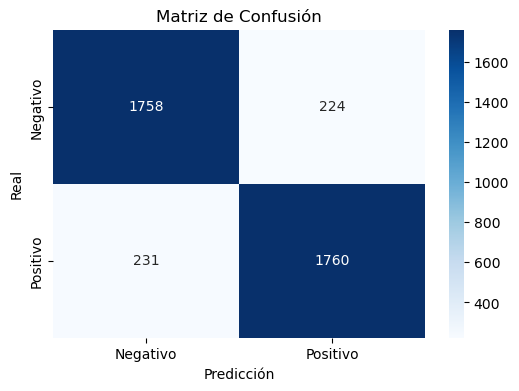

In [22]:
cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.savefig("fig2a_confusion_base.png", dpi=150, bbox_inches="tight")
plt.show()
plt.show()

### 11.1 Results Analysis

On the test set, the baseline `Bi-GRU` model achieves an accuracy of approximately `0.89` and a macro F1-score of approximately `0.89`, according to the classification report. Performance is balanced across classes, although there is a slight tendency to classify some negative reviews as positive.

The negative class achieves higher precision (`0.92`) than recall (`0.84`), while the positive class achieves higher recall (`0.93`) than precision (`0.85`). This indicates that the model is more effective at capturing positive reviews, but when it predicts a negative review, it tends to do so with higher precision.

## 12. Saved Checkpoint Verification

In [23]:
checkpoint = torch.load(MODEL_PATH, map_location=device)
print("Mejor modelo disponible")
print(f"- Ruta: {MODEL_PATH}")
print(f"- Época: {checkpoint['epoch']}")
print(f"- Val loss: {checkpoint['val_loss']:.4f}")
print(f"- Tokens en vocabulario guardado: {len(checkpoint['vocab'])}")

Mejor modelo disponible
- Ruta: c:\Users\Sergio\Documents\GitHub\microproyecto-02-tdl\best_sentiment_gru_checkpoint.pth
- Época: 4
- Val loss: 0.2974
- Tokens en vocabulario guardado: 10002


## 13. Additional Experiment: Bi-GRU with GloVe

This section compares the baseline model, which learns embeddings from scratch, against a variant initialized with 100-dimensional pretrained `GloVe` embeddings. The remainder of the architecture remains unchanged so that the comparison isolates the effect of initializing the `Embedding` layer.

In [24]:
if not GLOVE_PATH.exists():
    raise FileNotFoundError(f"No se encontró el archivo GloVe en: {GLOVE_PATH}")

embedding_matrix = np.random.normal(0, 0.05, (VOCAB_SIZE, EMBEDDING_DIM)).astype("float32")
embedding_matrix[vocab["<PAD>"]] = np.zeros(EMBEDDING_DIM, dtype="float32")


def looks_like_binary_embedding(path):
    with open(path, "rb") as file:
        header = file.readline().decode("utf-8", errors="ignore").split()
        sample = file.read(200)

    return len(header) == 2 and all(item.isdigit() for item in header) and any(byte > 127 for byte in sample)


def load_text_embeddings_into_matrix(path, vocab, embedding_matrix):
    hits = 0
    with open(path, encoding="utf-8") as file:
        for line_number, line in enumerate(file):
            values = line.rstrip().split()

            # Some Word2Vec-style files include a header line: "400000 100".
            if line_number == 0 and len(values) == 2 and all(value.isdigit() for value in values):
                continue

            word = values[0]
            vector = values[1:]

            if word in vocab and len(vector) == EMBEDDING_DIM:
                embedding_matrix[vocab[word]] = np.asarray(vector, dtype="float32")
                hits += 1

    return hits


def load_binary_word2vec_into_matrix(path, vocab, embedding_matrix):
    hits = 0
    with open(path, "rb") as file:
        total_words, vector_size = map(int, file.readline().split())

        if vector_size != EMBEDDING_DIM:
            raise ValueError(f"El embedding tiene dimensión {vector_size}, pero EMBEDDING_DIM={EMBEDDING_DIM}.")

        for _ in range(total_words):
            word_bytes = bytearray()

            while True:
                char = file.read(1)
                if char == b" ":
                    break
                if char != b"\n":
                    word_bytes.extend(char)

            word = word_bytes.decode("utf-8", errors="ignore")
            vector = np.frombuffer(file.read(4 * vector_size), dtype=np.float32)

            if word in vocab:
                embedding_matrix[vocab[word]] = vector
                hits += 1

    return hits


if looks_like_binary_embedding(GLOVE_PATH):
    hits = load_binary_word2vec_into_matrix(GLOVE_PATH, vocab, embedding_matrix)
    embedding_format = "Word2Vec binario"
else:
    hits = load_text_embeddings_into_matrix(GLOVE_PATH, vocab, embedding_matrix)
    embedding_format = "texto"

print(f"Archivo de embeddings: {GLOVE_PATH}")
print(f"Formato detectado: {embedding_format}")
print(f"Cobertura embeddings: {hits:,}/{VOCAB_SIZE:,} = {hits / VOCAB_SIZE:.2%}")

Archivo de embeddings: c:\Users\Sergio\Documents\GitHub\microproyecto-02-tdl\embeddings\glove.6B.100d
Formato detectado: texto
Cobertura embeddings: 9,905/10,002 = 99.03%


In [25]:
class SentimentGRUGloVe(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, n_layers, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix),
            freeze=False,
            padding_idx=vocab["<PAD>"],
        )
        self.gru = nn.GRU(
            EMBEDDING_DIM,
            hidden_dim,
            num_layers=n_layers,
            dropout=dropout,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, hidden = self.gru(embedded)
        hidden_cat = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        return self.fc(self.dropout(hidden_cat))


glove_model = SentimentGRUGloVe(
    embedding_matrix,
    HIDDEN_DIM,
    OUTPUT_DIM,
    N_LAYERS,
    dropout=DROPOUT,
).to(device)

glove_criterion = nn.BCEWithLogitsLoss()
glove_optimizer = torch.optim.Adam(glove_model.parameters(), lr=LEARNING_RATE)

print(glove_model)
print(f"Parámetros entrenables: {sum(p.numel() for p in glove_model.parameters() if p.requires_grad):,}")

SentimentGRUGloVe(
  (embedding): Embedding(10002, 100, padding_idx=0)
  (gru): GRU(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Parámetros entrenables: 1,473,545


In [26]:
glove_history = []
glove_best_val_loss = float("inf")
glove_patience = 3
glove_epochs_no_improve = 0
for epoch in range(EPOCHS):
    glove_model.train()
    train_loss = 0
    train_bar = tqdm(train_loader, desc=f"GloVe Epoch {epoch + 1}/{EPOCHS} [Train]")

    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        glove_optimizer.zero_grad()
        output = glove_model(inputs)
        loss = glove_criterion(output.squeeze(), labels)
        loss.backward()
        glove_optimizer.step()
        train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    glove_model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            output = glove_model(inputs)
            loss = glove_criterion(output.squeeze(), labels)
            val_loss += loss.item()

            probs = torch.sigmoid(output.squeeze())
            predicted = (probs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total
    glove_history.append({"epoch": epoch + 1, "train_loss": avg_train_loss, "val_loss": avg_val_loss, "val_accuracy": accuracy})

    if avg_val_loss < glove_best_val_loss:
        glove_best_val_loss = avg_val_loss
        glove_epochs_no_improve = 0
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": glove_model.state_dict(),
                "optimizer_state_dict": glove_optimizer.state_dict(),
                "val_loss": glove_best_val_loss,
                "vocab": vocab,
                "max_len": MAX_LEN,
            },
            GLOVE_MODEL_PATH,
        )
        checkpoint_message = "| Mejor modelo GloVe guardado"
    else:
        checkpoint_message = ""
        glove_epochs_no_improve += 1          
        if glove_epochs_no_improve >= glove_patience:  
            print(f"Early stopping en época {epoch + 1}")  
            break
    print()
    print(f"GloVe Summary Epoch {epoch + 1}:")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {accuracy:.2f}% {checkpoint_message}")
    print("-" * 30)

glove_checkpoint = torch.load(GLOVE_MODEL_PATH, map_location=device)
glove_model.load_state_dict(glove_checkpoint["model_state_dict"])
print(f"Mejor modelo GloVe cargado desde época {glove_checkpoint['epoch']} con val_loss={glove_checkpoint['val_loss']:.4f}")

GloVe Epoch 1/15 [Train]: 100%|██████████| 497/497 [25:21<00:00,  3.06s/it, loss=0.182]



GloVe Summary Epoch 1:
Train Loss: 0.4809 | Val Loss: 0.3260 | Val Acc: 86.13% | Mejor modelo GloVe guardado
------------------------------


GloVe Epoch 2/15 [Train]: 100%|██████████| 497/497 [22:05<00:00,  2.67s/it, loss=0.356]



GloVe Summary Epoch 2:
Train Loss: 0.2860 | Val Loss: 0.3140 | Val Acc: 86.56% | Mejor modelo GloVe guardado
------------------------------


GloVe Epoch 3/15 [Train]: 100%|██████████| 497/497 [23:13<00:00,  2.80s/it, loss=0.235] 


...


GloVe Summary Epoch 4:
Train Loss: 0.1997 | Val Loss: 0.3006 | Val Acc: 88.82% 
------------------------------


GloVe Epoch 5/15 [Train]: 100%|██████████| 497/497 [22:13<00:00,  2.68s/it, loss=0.249] 



GloVe Summary Epoch 5:
Train Loss: 0.1653 | Val Loss: 0.3139 | Val Acc: 87.97% 
------------------------------


GloVe Epoch 6/15 [Train]: 100%|██████████| 497/497 [19:02<00:00,  2.30s/it, loss=0.169] 


Early stopping en época 6
Mejor modelo GloVe cargado desde época 3 con val_loss=0.2692


In [27]:
glove_checkpoint = torch.load(GLOVE_MODEL_PATH, map_location=device)
glove_model.load_state_dict(glove_checkpoint["model_state_dict"])
glove_model.eval()

glove_pred_list = []
glove_true_list = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = glove_model(inputs)
        probs = torch.sigmoid(outputs.squeeze())
        predictions = (probs > 0.5).float()
        glove_pred_list.extend(predictions.cpu().numpy())
        glove_true_list.extend(labels.numpy())

print(f"Checkpoint GloVe evaluado: época {glove_checkpoint['epoch']} | val_loss={glove_checkpoint['val_loss']:.4f}")
print()
print("===== REPORTE DE CLASIFICACIÓN FINAL - Bi-GRU + GloVe =====")
print(classification_report(glove_true_list, glove_pred_list, target_names=["Negativo", "Positivo"]))

Checkpoint GloVe evaluado: época 3 | val_loss=0.2692

===== REPORTE DE CLASIFICACIÓN FINAL - Bi-GRU + GloVe =====
              precision    recall  f1-score   support

    Negativo       0.90      0.88      0.89      1982
    Positivo       0.88      0.90      0.89      1991

    accuracy                           0.89      3973
   macro avg       0.89      0.89      0.89      3973
weighted avg       0.89      0.89      0.89      3973



### 13.1 Analysis of the GloVe Experiment

The model with `GloVe` embeddings reaches its optimal validation range in early epochs, around epochs `3` and `4`. On the test set, it achieves an accuracy of approximately `0.89` and a macro F1-score of approximately `0.89`, comparable to the baseline model.

The primary improvement lies in convergence speed and lower validation loss. In addition, training with GloVe uses early stopping with `patience = 3`, stopping when validation stops improving.

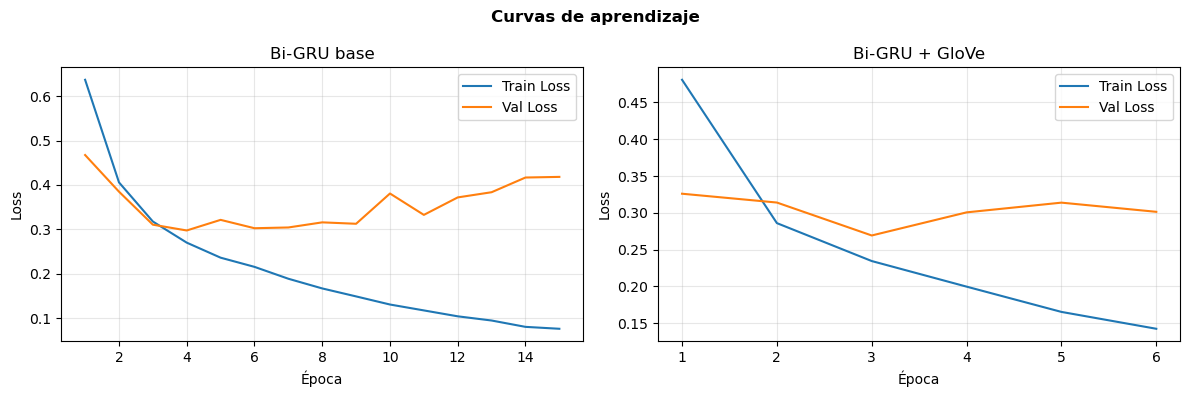

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Curvas de aprendizaje", fontsize=12, fontweight="bold")

# Baseline model
epochs_base = [h["epoch"] for h in history]
axes[0].plot(epochs_base, [h["train_loss"] for h in history], label="Train Loss")
axes[0].plot(epochs_base, [h["val_loss"] for h in history], label="Val Loss")
axes[0].set_title("Bi-GRU base")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# GloVe model
epochs_glove = [h["epoch"] for h in glove_history]
axes[1].plot(epochs_glove, [h["train_loss"] for h in glove_history], label="Train Loss")
axes[1].plot(epochs_glove, [h["val_loss"] for h in glove_history], label="Val Loss")
axes[1].set_title("Bi-GRU + GloVe")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig1_curvas.png", dpi=150, bbox_inches="tight")
plt.show()

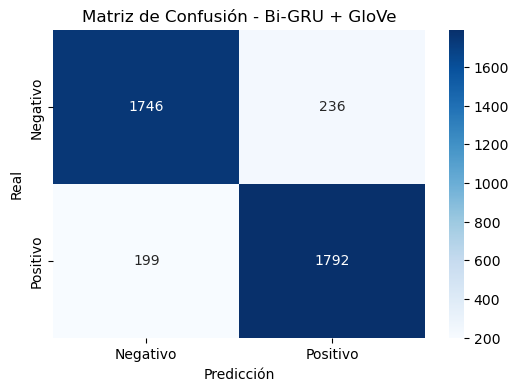

In [29]:
glove_cm = confusion_matrix(glove_true_list, glove_pred_list)
plt.figure(figsize=(6,4))
sns.heatmap(glove_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Bi-GRU + GloVe')
plt.savefig("fig2b_confusion_glove.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Additional Testing with External Examples

An inference function is defined to test novel sentences. While these tests do not replace quantitative evaluation, they help observe model behavior on simple reviews, sarcasm, negations, and mixed sentiments.

In [72]:
def predict_sentiment_final(text, model, vocab, max_len=MAX_LEN):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    sequence = [vocab.get(word, 1) for word in text.split()]
    
    if len(sequence) > max_len:
        sequence = sequence[:max_len]
    else:
        sequence = sequence + [0] * (max_len - len(sequence))
        
    tensor = torch.LongTensor(sequence).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probability = torch.sigmoid(output).item()
        
    sentiment = "Positivo" if probability > 0.5 else "Negativo"
    print(f"\"{text[:50]}...\"")
    print(f"Confianza: {probability:.4f} | Veredicto: {sentiment}")
    return sentiment, probability

In [73]:
# --- Test with external examples ---
_ = predict_sentiment_final("The movie was incredibly good, I loved the plot", model, vocab, MAX_LEN)
_ = predict_sentiment_final("It was a waste of time, terrible acting and boring", model, vocab, MAX_LEN)

"the movie was incredibly good i loved the plot..."
Confianza: 0.9526 | Veredicto: Positivo
"it was a waste of time terrible acting and boring..."
Confianza: 0.0020 | Veredicto: Negativo


In [74]:
_ = predict_sentiment_final("Oh, great, another masterpiece of boredom. I really enjoyed wasting two hours of my life", model, vocab, MAX_LEN)
_ = predict_sentiment_final("The acting was amazing, the music was beautiful, the cinematography was world-class, but the script was so incredibly bad that it ruined the whole experience.", model, vocab, MAX_LEN)

"oh great another masterpiece of boredom i really e..."
Confianza: 0.9632 | Veredicto: Positivo
"the acting was amazing the music was beautiful the..."
Confianza: 0.0506 | Veredicto: Negativo


In [75]:
_ = predict_sentiment_final("I can't say that I didn't like it, but I wouldn't watch it again even if you paid me.", model, vocab, MAX_LEN)
_ = predict_sentiment_final("The cinematic execution was rather lackluster and the narrative felt somewhat pedestrian", model, vocab, MAX_LEN)

"i cant say that i didnt like it but i wouldnt watc..."
Confianza: 0.2687 | Veredicto: Negativo
"the cinematic execution was rather lackluster and ..."
Confianza: 0.0630 | Veredicto: Negativo


"the movie was incredibly good i loved the plot..."
Confianza: 0.9526 | Veredicto: Positivo
"it was a waste of time terrible acting and boring..."
Confianza: 0.0020 | Veredicto: Negativo
"oh great another masterpiece of boredom i really e..."
Confianza: 0.9524 | Veredicto: Positivo
"i cant say that i didnt like it but i wouldnt watc..."
Confianza: 0.1928 | Veredicto: Negativo


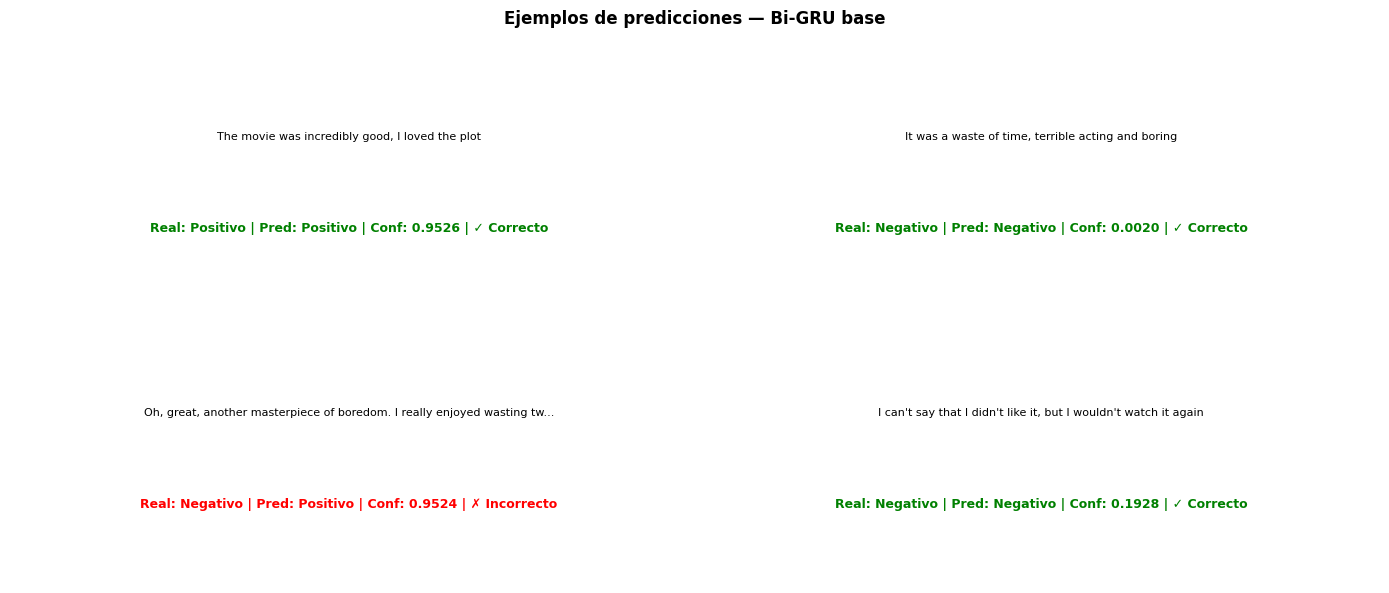

In [76]:
ejemplos = [
    ("The movie was incredibly good, I loved the plot", "Positivo"),
    ("It was a waste of time, terrible acting and boring", "Negativo"),
    ("Oh, great, another masterpiece of boredom. I really enjoyed wasting two hours", "Negativo"),
    ("I can't say that I didn't like it, but I wouldn't watch it again", "Negativo"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle("Ejemplos de predicciones — Bi-GRU base", fontsize=12, fontweight="bold")

for idx, (text, real) in enumerate(ejemplos):
    ax = axes[idx // 2, idx % 2]
    pred, prob = predict_sentiment_final(text, model, vocab, MAX_LEN)
    color = "green" if pred == real else "red"
    estado = "✓ Correcto" if pred == real else "✗ Incorrecto"
    short_text = text[:70] + "..." if len(text) > 70 else text
    ax.text(0.5, 0.65, short_text, ha='center', va='center',
            fontsize=8, transform=ax.transAxes, wrap=True)
    ax.text(0.5, 0.3, f"Real: {real} | Pred: {pred} | Conf: {prob:.4f} | {estado}",
            ha='center', va='center', fontsize=9,
            color=color, fontweight='bold', transform=ax.transAxes)
    ax.set_facecolor("#f9f9f9")
    ax.axis("off")

plt.tight_layout()
plt.savefig("fig3_cualitativos.png", dpi=150, bbox_inches="tight")
plt.show()

### 14.1 Conclusions from Manual Testing

Simple tests show coherent predictions on clearly positive or negative sentences. For more ambiguous examples, such as double negations or sarcasm, behavior is less consistent. This is expected from an RNN trained with scratch embeddings, as phenomena such as irony, complex semantic composition, and polarity shifts require broader context and potentially more robust linguistic representations.

## 15. Conclusions

A complete pipeline for sentiment classification on IMDb reviews was built using a `Bi-GRU` recurrent neural network. The workflow includes duplicate removal, text cleaning, review length analysis, stratified splitting, vocabulary construction strictly on the training set, tokenization, padding, training, and evaluation.

Both the baseline model and the model with `GloVe` embeddings achieved test accuracy and macro F1-scores near `0.89`. The benefit of GloVe is observed not so much in final accuracy or F1, but primarily in lower validation loss and faster convergence. This suggests that pre-trained semantic representations facilitate training, although the dataset is large enough for the baseline model to learn effective embeddings as well.

For future work, it would be valuable to compare against an `LSTM`, perform systematic hyperparameter tuning, and conduct a more granular error analysis on reviews featuring sarcasm, negation, or mixed sentiments.

## 16. References

- Dataset: Yasser H. *IMDb Movie Ratings Sentiment Analysis*. Kaggle. Available at: https://www.kaggle.com/datasets/yasserh/imdb-movie-ratings-sentiment-analysis/data
- Cho, K. et al. (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation*. arXiv:1406.1078.
- Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation.
- PyTorch. *GRU documentation*. Available at: https://pytorch.org/docs/stable/generated/torch.nn.GRU.html